# Cross-Asset Correlation Analysis

This notebook studies how selected crypto, equity, commodity, and currency-market proxies move relative to each other using daily returns. It downloads price data from Yahoo Finance, cleans missing values, computes a return correlation matrix, and visualizes the result with static and interactive heatmaps.


## 1. Import Libraries


In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
import yfinance as yf

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")


## 2. Configuration

Update `TICKERS`, `START_DATE`, or `END_DATE` if you want to analyze a different set of assets or time period.


In [2]:
TICKERS = {
    "Bitcoin": "BTC-USD",
    "Ethereum": "ETH-USD",
    "Gold Futures": "GC=F",
    "S&P 500 ETF": "SPY",
    "U.S. Dollar Index": "DX-Y.NYB",
}

START_DATE = "2021-01-01"
END_DATE = pd.Timestamp.today().strftime("%Y-%m-%d")

print(f"Analysis window: {START_DATE} to {END_DATE}")


Analysis window: 2021-01-01 to 2026-06-14


## 3. Download Price Data

The analysis uses adjusted closing prices where available. Each ticker is downloaded separately so that a temporary failure is easier to identify.


In [3]:
def download_close_prices(tickers: dict[str, str], start_date: str, end_date: str) -> pd.DataFrame:
    """Download close prices from Yahoo Finance and return one column per asset."""
    prices = pd.DataFrame()

    for asset_name, ticker in tickers.items():
        raw = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            auto_adjust=True,
            progress=False,
        )

        if raw.empty:
            raise ValueError(f"No data returned for {asset_name} ({ticker}).")

        prices[asset_name] = raw["Close"]

    return prices


prices = download_close_prices(TICKERS, START_DATE, END_DATE)
prices.head()


,Bitcoin,Ethereum,Gold Futures,S&P 500 ETF,U.S. Dollar Index
Date,,,,,
2021-01-01,29374.152344,730.367554,NaN,NaN,NaN
2021-01-02,32127.267578,774.534973,NaN,NaN,NaN
2021-01-03,32782.023438,975.507690,NaN,NaN,NaN
2021-01-04,31971.914062,1040.233032,1944.699951,343.319153,89.879997
2021-01-05,33992.429688,1100.006104,1952.699951,345.683685,89.440002


## 4. Clean the Data

Different markets do not trade on exactly the same calendar. Forward filling handles short holiday/weekend gaps, and `dropna` removes rows before all assets have data.


In [4]:
missing_before = prices.isna().sum().rename("missing_before")
clean_prices = prices.ffill().dropna()
missing_after = clean_prices.isna().sum().rename("missing_after")

pd.concat([missing_before, missing_after], axis=1)


,missing_before,missing_after
Bitcoin,0,0
Ethereum,0,0
Gold Futures,621,0
S&P 500 ETF,623,0
U.S. Dollar Index,621,0


## 5. Calculate Daily Returns

Correlations are calculated on daily percentage returns rather than price levels because the assets have very different price scales.


In [5]:
daily_returns = clean_prices.pct_change().dropna()
daily_returns.head()


,Bitcoin,Ethereum,Gold Futures,S&P 500 ETF,U.S. Dollar Index
Date,,,,,
2021-01-05,0.063197,0.057461,0.004114,0.006887,-0.004895
2021-01-06,0.083311,0.097369,-0.023455,0.005978,0.001006
2021-01-07,0.069157,0.015380,0.002832,0.014858,0.003351
2021-01-08,0.036234,-0.001208,-0.040893,0.005698,0.003006
2021-01-09,-0.013311,0.046463,0.000000,0.000000,0.000000


## 6. Correlation Matrix

The matrix below shows Pearson correlations between daily asset returns.


In [6]:
corr_matrix = daily_returns.corr()
corr_matrix


,Bitcoin,Ethereum,Gold Futures,S&P 500 ETF,U.S. Dollar Index
Bitcoin,1.000000,0.820979,0.054192,0.358740,-0.139585
Ethereum,0.820979,1.000000,0.057445,0.369342,-0.138604
Gold Futures,0.054192,0.057445,1.000000,0.099069,-0.390864
S&P 500 ETF,0.358740,0.369342,0.099069,1.000000,-0.238823
U.S. Dollar Index,-0.139585,-0.138604,-0.390864,-0.238823,1.000000


## 7. Static Heatmap


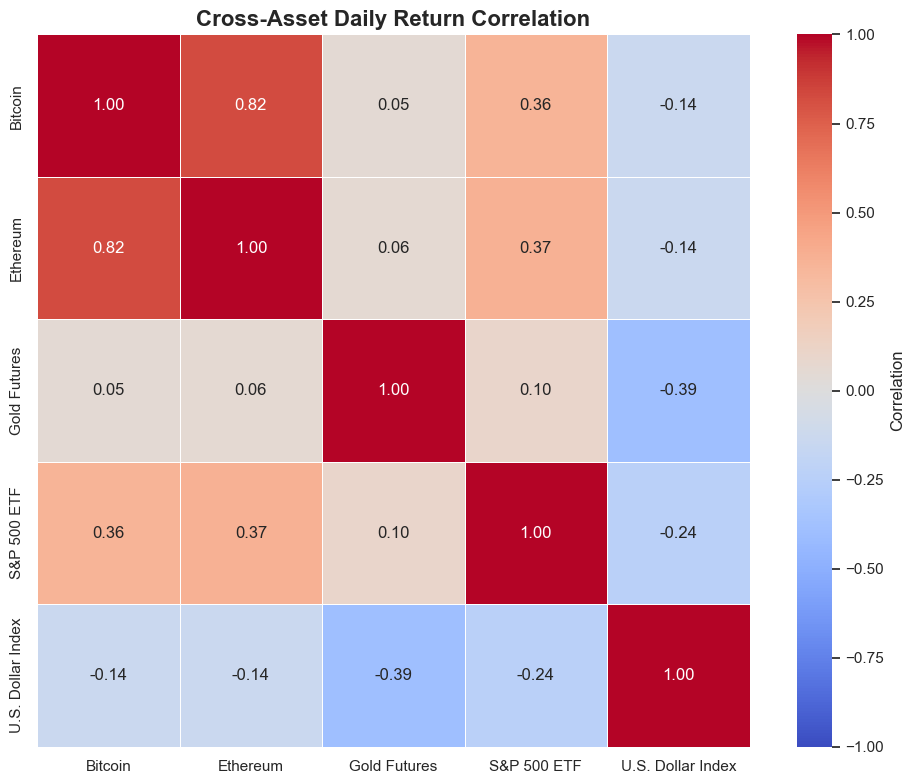

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation"},
)
plt.title("Cross-Asset Daily Return Correlation", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


## 8. Interactive Plotly Heatmap


In [8]:
fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    aspect="auto",
    title="Cross-Asset Daily Return Correlation Heatmap",
)

fig.update_layout(
    width=850,
    height=650,
    title_x=0.5,
    font=dict(size=13),
)

fig.show()


## 9. Interpretation Guide

- Correlation close to `1`: the assets tended to move in the same direction.
- Correlation close to `0`: the relationship was weak or inconsistent.
- Correlation close to `-1`: the assets tended to move in opposite directions.

Remember that correlation does not imply causation, and cross-asset relationships can change across market regimes.
